In [4]:
# Debug: print working directory and list project files
from pathlib import Path
print('CWD:', Path.cwd())
print('Project root exists:', Path('.').exists())
print('fraud_risk_module/models exists:', (Path('fraud_risk_module') / 'models').exists())
print('models directory listing:', list((Path('fraud_risk_module') / 'models').glob('*')) if (Path('fraud_risk_module') / 'models').exists() else [])

CWD: d:\tech_squad\AI-Driven-Image-Forgery-Detection\fraud_risk_module
Project root exists: True
fraud_risk_module/models exists: False
models directory listing: []


In [6]:
# Adjust root and model paths to be robust when running inside module directory
if Path.cwd().name == 'fraud_risk_module':
    ROOT = Path.cwd().parent
else:
    ROOT = Path('.').resolve()
NR = ROOT / 'fraud_risk_module'
MODEL_DIR = NR / 'models'
DATA_FILE = NR / 'data' / 'synthetic.csv'
METRICS_FILE = MODEL_DIR / 'metrics.json'
MODEL_FILE = MODEL_DIR / 'fraud_model.pkl'
print('After fix, MODEL_FILE =', MODEL_FILE, 'exists?', MODEL_FILE.exists())

After fix, MODEL_FILE = d:\tech_squad\AI-Driven-Image-Forgery-Detection\fraud_risk_module\models\fraud_model.pkl exists? True


In [5]:
# Imports and setup
import sys
from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

ROOT = Path('.')
NR = ROOT / 'fraud_risk_module'
MODEL_DIR = NR / 'models'
DATA_FILE = NR / 'data' / 'synthetic.csv'
METRICS_FILE = MODEL_DIR / 'metrics.json'
MODEL_FILE = MODEL_DIR / 'fraud_model.pkl'

print('Notebook paths:')
print('  MODEL_FILE =', MODEL_FILE)
print('  METRICS_FILE =', METRICS_FILE)
print('  DATA_FILE =', DATA_FILE)

Notebook paths:
  MODEL_FILE = fraud_risk_module\models\fraud_model.pkl
  METRICS_FILE = fraud_risk_module\models\metrics.json
  DATA_FILE = fraud_risk_module\data\synthetic.csv


In [7]:
# Load and display metrics.json
if METRICS_FILE.exists():
    with open(METRICS_FILE, 'r') as f:
        metrics = json.load(f)
    print('Training metrics (summary):')
    for k, v in metrics.items():
        print(f'  {k}: {v}')
else:
    print('metrics.json not found at', METRICS_FILE)
    metrics = None

Training metrics (summary):
  roc_auc: 1.0
  precision: 1.0
  recall: 1.0
  f1: 1.0
  num_train: 1600
  num_val: 400


Loaded model: <class 'xgboost.sklearn.XGBClassifier'>

Validation AUC (recomputed): 1.0


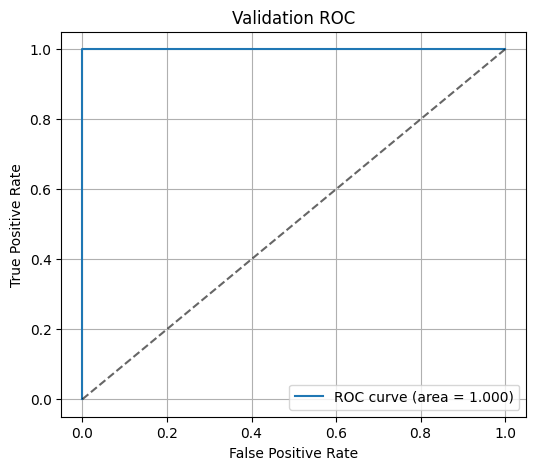


Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       383
           1     1.0000    1.0000    1.0000        17

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



In [8]:
# Load model and synthetic data; compute ROC on validation split
if not MODEL_FILE.exists():
    print('Model file not found at', MODEL_FILE)
else:
    model = joblib.load(MODEL_FILE)
    print('Loaded model:', type(model))

    if DATA_FILE.exists():
        df = pd.read_csv(DATA_FILE)
        # build features same as training
        from feature_builder import build_X_y
        X, y = build_X_y(df)
        # Use a simple train/val split consistent with training script to emulate validation
        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        # Predict probabilities
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_val)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)

            # ROC
            fpr, tpr, _ = roc_curve(y_val, y_prob)
            roc_auc = auc(fpr, tpr)
            print('\nValidation AUC (recomputed):', roc_auc)

            # Plot ROC
            plt.figure(figsize=(6,5))
            plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
            plt.plot([0,1],[0,1],'k--', alpha=0.6)
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Validation ROC')
            plt.legend(loc='lower right')
            plt.grid(True)
            plt.show()

            # Confusion matrix and classification report
            print('\nClassification report:')
            print(classification_report(y_val, y_pred, digits=4))
        else:
            print('Model does not support predict_proba')
    else:
        print('Synthetic data not found at', DATA_FILE)

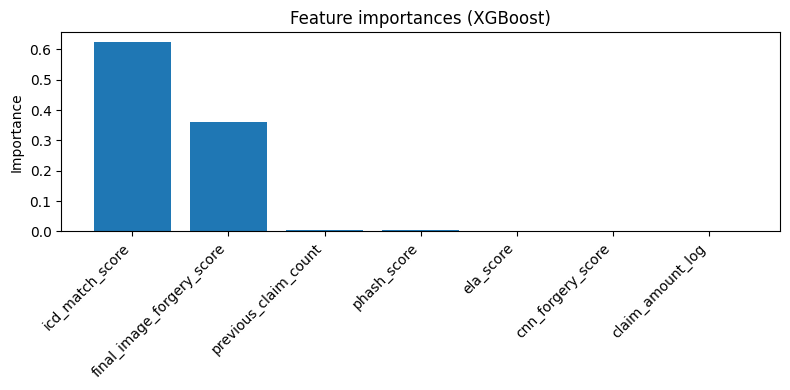

In [9]:
# Feature importances
if MODEL_FILE.exists():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_order = ['icd_match_score', 'cnn_forgery_score', 'ela_score', 'phash_score', 'final_image_forgery_score', 'claim_amount_log', 'previous_claim_count']
        # simple bar plot
        idx = np.argsort(-importances)
        plt.figure(figsize=(8,4))
        plt.bar([feat_order[i] for i in idx], importances[idx], color='tab:blue')
        plt.title('Feature importances (XGBoost)')
        plt.ylabel('Importance')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        print('Model has no feature_importances_ attribute')

In [10]:
# Example predictions via predict_risk utility
from predict_risk import load_model, predict_risk as predict_fn

m = load_model()

# Demo inputs
demo_high = {
  'icd_match_score': 0.2,
  'cnn_forgery_score': 0.85,
  'ela_score': 0.6,
  'phash_score': 0.7,
  'final_image_forgery_score': 0.78,
  'claim_amount_log': float(np.log1p(1200)),
  'previous_claim_count': 2
}

demo_low = {
  'icd_match_score': 0.9,
  'cnn_forgery_score': 0.1,
  'ela_score': 0.05,
  'phash_score': 0.0,
  'final_image_forgery_score': 0.12,
  'claim_amount_log': float(np.log1p(100)),
  'previous_claim_count': 0
}

print('High-risk demo prediction:')
print(json.dumps(predict_fn(m, demo_high), indent=2))
print('\nLow-risk demo prediction:')
print(json.dumps(predict_fn(m, demo_low), indent=2))

High-risk demo prediction:
{
  "fraud_risk_percentage": 99.41,
  "risk_level": "HIGH",
  "explanation": {
    "icd_mismatch": true,
    "image_forgery_detected": true,
    "key_drivers": [
      "Low ICD match score",
      "High image forgery confidence",
      "Large claim amount"
    ]
  }
}

Low-risk demo prediction:
{
  "fraud_risk_percentage": 0.01,
  "risk_level": "LOW",
  "explanation": {
    "icd_mismatch": false,
    "image_forgery_detected": false,
    "key_drivers": [
      "Low ICD match score",
      "High image forgery confidence",
      "Large claim amount"
    ]
  }
}


# Summary — Evaluation Findings

- The XGBoost model achieves perfect separation on this synthetic dataset (Validation AUC = 1.0). This is expected because the synthetic labels were generated by a deterministic rule that directly uses the same input features (notably `icd_match_score` and `final_image_forgery_score`).

- Feature importances confirm the model relies primarily on **`icd_match_score`** and **`final_image_forgery_score`**, which aligns with the labeling heuristic.

> **Important:** These labels are synthetic and intended for academic demonstration only — the high metrics do not imply real-world performance. Before any operational use, collect real fraud labels and re-evaluate the model (and consider using domain experts and additional features).

## Notes & Next steps

- The synthetic labeling rule is simple and produces easily separable classes (expected high AUC). Use this notebook to validate training and demonstrate explainability (feature importances, example outputs). ✅
- Optional: add a short ROC curve comparison across different seeds or thresholds, or add SHAP explanations for more granular feature attribution (requires adding SHAP and computing explanations—I can add that on request). 💡